In [21]:
from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import mdtraj as md

In [90]:
def add_ordinal_suffix(n):
    """
    Add the appropriate ordinal suffix ('st', 'nd', 'rd', 'th') to an integer.

    Args:
        n (int): The integer to which the ordinal suffix should be added.

    Returns:
        str: The integer as a string with the appropriate ordinal suffix.
    """
    # Handle special cases for 11, 12, 13
    if 10 <= n % 100 <= 13:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    
    return f"{n}{suffix}"

In [6]:
def dir_to_trj(path, load_cells=False):
    
    pdb_list = glob(path + '/*.pdb')
    print('found %d hit pdbs' % len(pdb_list))

    structures = None
    cells = []
    
    for pdb in tqdm(pdb_list):

        try:

            trj = md.load_pdb(pdb)
            idx = trj.top.select('(type != H) and is_protein and (name == CA)')
            trj = trj.atom_slice(idx)

            if structures:
                structures = structures.join(trj)
            else:
                structures = trj
                
            if load_cells:
                cell = np.concatenate( [trj.unitcell_lengths[0]*10.0,
                                        trj.unitcell_angles[0], 
                                        trj.unitcell_volumes] )
                cells.append(cell)

        except Exception as e:
            print(pdb, e)
            print(trj.n_atoms, structures.n_atoms)

    structures = structures.center_coordinates()
    print('final num loaded:', len(structures))

    if load_cells:
        cells = np.array(cells)
        return structures, cells
    else:
        return structures

In [7]:
SELECTED_DATASET_PDBS = '/Users/tjlane/Desktop/selected_dataset_archive_2024-08-07/pdb'
apo_calpha = dir_to_trj(SELECTED_DATASET_PDBS, load_cells=False)

found 1146 hit pdbs


100%|██████████| 1146/1146 [01:41<00:00, 11.32it/s]

final num loaded: 1146


In [144]:
mean_structure = apo_calpha[0]
mean_structure.xyz[0] = apo_calpha.xyz.mean(axis=0)

per_atom_per_xyz_rmsd = np.std(apo_calpha.xyz * 10.0, axis=0)  # mdtraj uses nm
per_structure_rmsd = md.rmsd(apo_calpha, mean_structure, precentered=False) * 10.0
per_atom_average_rmsd = np.mean(per_atom_per_xyz_rmsd, axis=1)

print(apo_calpha.xyz.shape, per_atom_per_xyz_rmsd.shape, per_atom_average_rmsd.shape, per_structure_rmsd.shape)

(1146, 306, 3) (306, 3) (306,) (1146,)


In [145]:
number_atoms_to_show = 6
subsample_factor = len(per_atom_average_rmsd) // number_atoms_to_show

atoms_shown = [i * subsample_factor + 1 for i in range(number_atoms_to_show)]

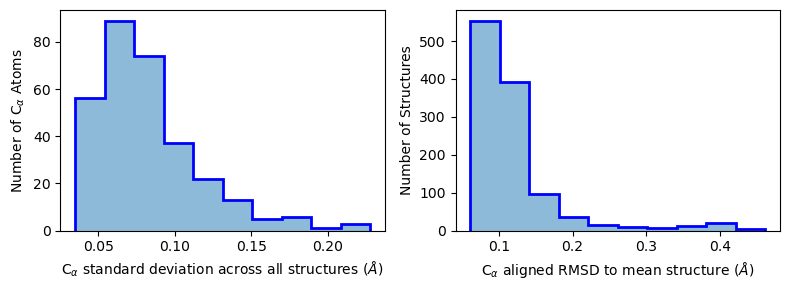

In [148]:
bins = None #np.linspace(0.0, 0.25, 25)

plt.figure(figsize=(8,3))

plt.subplot(121)
plt.hist(per_atom_average_rmsd, alpha=0.5, lw=2, bins=bins)
plt.hist(per_atom_average_rmsd, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"C$_\alpha$ standard deviation across all structures ($\AA$)")
plt.ylabel(r"Number of C$_\alpha$ Atoms")

plt.subplot(122)
plt.hist(per_structure_rmsd, alpha=0.5, lw=2, bins=bins)
plt.hist(per_structure_rmsd, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"C$_\alpha$ aligned RMSD to mean structure ($\AA$)")
plt.ylabel(r"Number of Structures")

plt.tight_layout()
plt.savefig("./Calpha_displacement_summary.png")
plt.show()

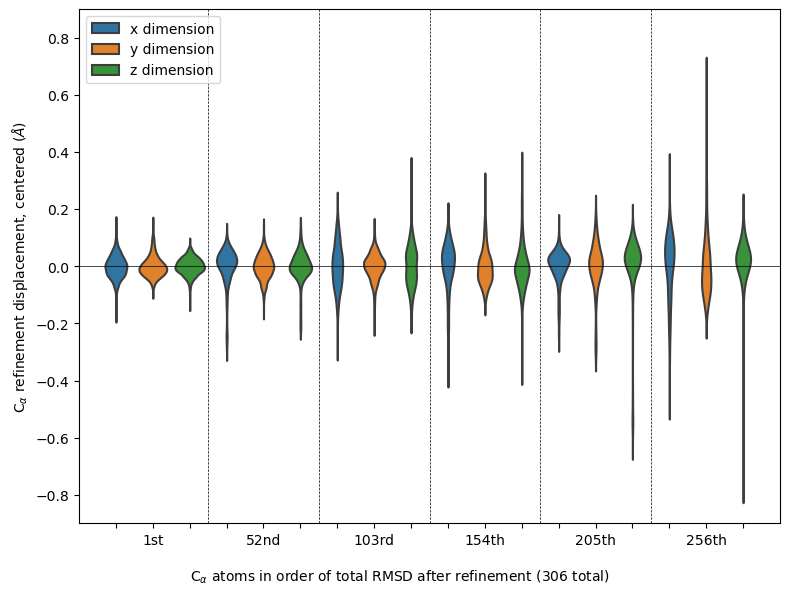

In [149]:
# compute an array that is (samples, n_atoms*3), where the 3 is x/y/z
# sorted by the atom's RMSD in the ensemble... ie less mobile atoms during refinement 
# to the left, more mobile to the right
sorted_xyz = apo_calpha.xyz[:,np.argsort(per_atom_average_rmsd),:][:,::subsample_factor,:]  * 10.0 # dont forget unit conversion
sorted_xyz = sorted_xyz.reshape(sorted_xyz.shape[0], -1)
sorted_xyz -= sorted_xyz.mean(axis=0)[None,:]

xyz_data = pd.DataFrame(sorted_xyz)

# -----------------------------

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

sns.violinplot(
    data=xyz_data,
    inner=None,
    palette=colors,
)

ax.legend(["x dimension", "y dimension", "z dimension"], loc=2)
ax.set_ylabel(r"C$_\alpha$ refinement displacement, centered ($\AA$)")

xticklabels = []
for atom_shown in atoms_shown:
    xticklabels.extend(["", f"{add_ordinal_suffix(atom_shown)}", ""] )
ax.set_xticklabels(
    xticklabels
)

bottom_label = r"C$_\alpha$ atoms in order of total RMSD after refinement (306 total)"
ax.text(2, -1.1, bottom_label)

ylim = 0.9
for n in range(number_atoms_to_show-1):
    plt.vlines(n*3+2.5, -ylim, ylim, color='k', linestyle="--", lw=0.5)
ax.set_ylim([-ylim, ylim])

ax.hlines(0.0, -2, number_atoms_to_show*3+1, color="k", lw=0.5)
ax.set_xlim([-1, number_atoms_to_show*3])

plt.tight_layout()
plt.savefig("./per-dimension-atom-position-distributions.png")
plt.show()